In [10]:
import pandas as pd 
df = pd.read_csv("data/accepted_2007_to_2018Q4.csv")

# target 생성
status_map = { 
    "Fully Paid" : 0 ,
    "Charged Off" :1, 
    "Default" : 1
}

df["target"] = df["loan_status"].map(status_map)
current_pay = df[df["target"].isnull()].copy() # 현재 상환중인
df = df[df["target"].notnull()].copy()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform
warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("=" * 60)
print("로드 완료")
print("=" * 60)

로드 완료


issue_year
2012     25626
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


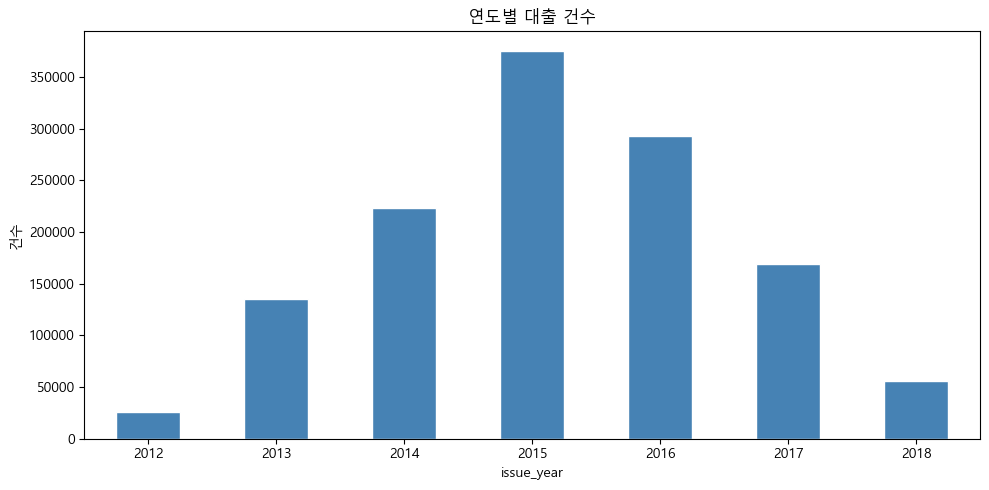

In [12]:
# 변경 정책 반영 
# 연도 자르기 
change_mask = "num_actv_bc_tl" # num_actv_bc_tl 컬럼이 2015-12 이후에 도입된 컬럼이므로, 이 컬럼이 결측인 행들은 2015-12 이전 데이터로 간주하여 제거하기로 결정했습니다.
df = df.dropna(subset=[change_mask]) # df에서 num_actv_bc_tl 컬럼이 결측인 행들을 제거하는 코드입니다. 이렇게 하면 2015-12 이전 데이터가 제거되어 이후 분석에 현대적 데이터만 남게 됩니다.

#날짜형 변수 변환 
df['issue_d'] = pd.to_datetime(df['issue_d'], errors="coerce")
df['issue_year'] = df['issue_d'].dt.year

print(df['issue_year'].value_counts().sort_index())

df['issue_year'].value_counts().sort_index().plot(
    kind='bar', figsize=(10, 5), color='steelblue', edgecolor='white'
)
plt.title('연도별 대출 건수')
plt.ylabel('건수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
"""
제거 대상 컬럼
"""

drop_columns = [
    # ── 그룹 1: 사후 상환 실적 ──
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
    'total_rec_late_fee', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',

    # ── 그룹 2: 잔액 사후 정보 ──
    'out_prncp', 'out_prncp_inv',

    # ── 그룹 3: 상각/추심 사후 ──
    'recoveries', 'collection_recovery_fee',

    # ── 그룹 4: 사후 신용 스냅샷 ──
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # ── 그룹 5: Hardship / Settlement ──
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    'orig_projected_additional_accrued_interest',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',

    # ── 그룹 6: 특별 상환 계획 ──
    'pymnt_plan', 'payment_plan_start_date',

    # ── 그룹 7: 승인/집행 결과 ──
    'funded_amnt', 'funded_amnt_inv', 'disbursement_method',

    # ── 그룹 8: 식별자 및 상수 ──
    'id', 'member_id', 'url', 'title', 'zip_code', 'policy_code',

    # ── 그룹 9: 원본 타겟 변수 ──
    'loan_status',

    # ── 그룹 10: 효과 크기 낮은 변수 ── 후보 
    #'initial_list_status', 'total_acc', 'open_acc',
    #'application_type', 'addr_state', 'earliest_cr_line', 'pub_rec',

    # ── 그룹 11: 공동 신청(Joint) 관련 ──
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog',

    # 2016년 이후 신규 추가된 세부 신용 리포트 항목 (13개) 
    "open_acc_6m", "open_act_il", "open_il_12m", "open_il_24m","total_bal_il"
    ,"il_util","open_rv_12m","open_rv_24m","max_bal_bc","all_util","inq_fi" 
    ,"total_cu_tl", "inq_last_12m",

    # 3차 검토 사용 불가 판정 
    "desc", "emp_title", "num_tl_120dpd_2m", 

]

# 중복 검증
assert len(drop_columns) == len(set(drop_columns)), \
    f"중복 존재: {[c for c in drop_columns if drop_columns.count(c) > 1]}"

print(f"총 제거 대상: {len(drop_columns)}개")

# 실제 적용
df = df.drop(columns=[c for c in drop_columns if c in df.columns])

총 제거 대상: 80개


In [14]:
# 전체 컬럼의 null 여부 
null_info = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률': df.isnull().mean().apply(lambda x: f"{x:.2%}")
})
print(null_info[null_info['결측수'] > 0])

                                    결측수     결측률
emp_length                        76489   5.99%
dti                                 374   0.03%
inq_last_6mths                        1   0.00%
mths_since_last_delinq           634730  49.67%
mths_since_last_record          1052888  82.40%
revol_util                          776   0.06%
mths_since_last_major_derog      924066  72.32%
mths_since_rcnt_il               754404  59.04%
avg_cur_bal                          22   0.00%
bc_open_to_buy                    13593   1.06%
bc_util                           14349   1.12%
mo_sin_old_il_acct                38049   2.98%
mo_sin_old_rev_tl_op                  1   0.00%
mo_sin_rcnt_rev_tl_op                 1   0.00%
mths_since_recent_bc              12703   0.99%
mths_since_recent_bc_dlq         958794  75.03%
mths_since_recent_inq            124131   9.71%
mths_since_recent_revol_delinq   832949  65.19%
num_rev_accts                         1   0.00%
pct_tl_nvr_dlq                      154 

In [ ]:
"""
통합전처리
"""
# mo_sin_old_rev_tl_op이 null인 행 제거 
df = df.dropna(subset=["mo_sin_old_rev_tl_op"]) # null 1
df = df.dropna(subset=["num_rev_accts"]) # null 1


#날짜형 변수 변환 
#df['issue_d'] = pd.to_datetime(df['issue_d'], errors="coerce")
# df['issue_year'] = df['issue_d'].dt.year #연도별 변수 
#df['issue_month'] = df['issue_d'].dt.month # 월별 변수 

# 범주형 변수 처리
df["emp_length"] = df["emp_length"].fillna("unknown") # 근속 연수 결측치는  unknown 처리
df["home_ownership"] = df["home_ownership"].replace(["ANY","NONE"],"OTHER" ) # 주거 형태  OTHER 로 통합 

# 수치형 변수 처리
df["inq_last_6mths"] = df['inq_last_6mths'].fillna(0) #  최근 6개월간 신용 조회(hard inquiry) 횟수 결측치 1
df["revol_util"]= df["revol_util"].fillna(0) #리볼빙 이용률 (%) 
df["bc_open_to_buy"]= df["bc_open_to_buy"].fillna(0) #뱅크카드 잔여 한도 ($) 
df["bc_util"]= df["bc_util"].fillna(0) #뱅크카드 이용률 (%)
df["percent_bc_gt_75"]= df["percent_bc_gt_75"].fillna(0) #뱅크카드 75%인 뱅크카드 비율 (%) 
df["dti"] = df["dti"].replace(999, np.nan) # dti 변경전 >> 결측치 Null 로 변경
df.loc[df["dti"] < 0, "dti"] = np.nan

# 전체 계좌 평균 잔액 ($) 이 null 인행 제거 
df = df.dropna(subset=["avg_cur_bal"])

# 파생 변수 생성 
# 신용 조회, 결측이라면 연체가 없다는 의미 
cols = [
'mths_since_last_delinq',
'mths_since_last_record',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_rcnt_il', 
'mths_since_recent_inq', 
'mths_since_recent_bc'
]

for col in cols:
    df[col+"_flag"] = df[col].isna().astype(int) # 결측값일때 1 아닐때 0, 1이라는 것은 연체가 없다는 것 
    # max_val = df[col].max()
    # df[col] = df[col].fillna(max_val + 1) 


# # 대출 당시 신용 조회 평균 
df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high'])/2
df = df.drop(columns=['fico_range_low', 'fico_range_high']) # 제거 



# 기존 전처리통합과 다른점
- _missing을 _flag로
- is_pub_rec 제거

In [ ]:
# 전처리한 데이터 내보내기 
df.to_csv("data/lending_club_preprocessed.csv", index=False) # 

# 데이터 모델링 시작


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1) 데이터 로드
df = pd.read_csv("data/lending_club_preprocessed.csv")

In [2]:
df.isna().sum()

loan_amnt                        0
term                             0
int_rate                         0
installment                      0
grade                            0
                                ..
mths_since_recent_bc_dlq_flag    0
mths_since_rcnt_il_flag          0
mths_since_recent_inq_flag       0
mths_since_recent_bc_flag        0
fico_mid                         0
Length: 80, dtype: int64

In [51]:
df.isna().sum()[df.isna().sum() > 0]
missing_cols = df.columns[df.isna().sum() > 0].tolist()
print(missing_cols)

['dti', 'mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'mths_since_rcnt_il', 'mo_sin_old_il_acct', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'pct_tl_nvr_dlq']


# 데이터 결측치 처리 후 train, test 나누기

In [ ]:
# # grade별 중앙값으로 dti 결측치 채우기
# df["dti"] = df.groupby("grade")["dti"].transform(lambda x: x.fillna(x.median())) 

# cols = [
# 'mths_since_last_delinq', 
# 'mths_since_last_record', 
# 'mths_since_last_major_derog', 
# 'mths_since_rcnt_il', 
# 'mo_sin_old_il_acct', 
# 'mths_since_recent_bc', 
# 'mths_since_recent_bc_dlq', 
# 'mths_since_recent_inq', 
# 'mths_since_recent_revol_delinq'
# ]

# for col in cols:
#     max_val = df[col].max()
#     df[col] = df[col].fillna(max_val + 1)

# # pct_tl_nvr_dlq도 중앙값으로 채우기


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 공통 전처리 완료 df
# df = ...

target_col = "target"

# 1) split 먼저
X = df.drop(columns=[target_col]).copy() 
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2) 규칙 정의
dti_col = "dti"
pct_col = "pct_tl_nvr_dlq"
max_plus_cols = [c for c in missing_cols if c not in [dti_col, pct_col]]

# 3) train에서만 통계 계산
# 3-1) dti: grade별 중앙값 + (안전) 전체 중앙값 fallback
grade_dti_median = X_train.groupby("grade")[dti_col].median()
global_dti_median = X_train[dti_col].median()

# 3-2) pct_tl_nvr_dlq: 전체 중앙값
pct_median = X_train[pct_col].median() 

# 3-3) 나머지: max + 1
max_plus_values = {col: X_train[col].max() + 1 for col in max_plus_cols}

# 4) train 적용
# dti
train_mask = X_train[dti_col].isna()
X_train.loc[train_mask, dti_col] = X_train.loc[train_mask, "grade"].map(grade_dti_median)
X_train[dti_col] = X_train[dti_col].fillna(global_dti_median)  # 혹시 grade별 중앙값도 NaN이면 fallback

# pct_tl_nvr_dlq
X_train[pct_col] = X_train[pct_col].fillna(pct_median)

# max+1 cols
for col, fill_val in max_plus_values.items(): 
    X_train[col] = X_train[col].fillna(fill_val)

# 5) test 적용 (train에서 구한 값만 사용)
# dti
test_mask = X_test[dti_col].isna()
X_test.loc[test_mask, dti_col] = X_test.loc[test_mask, "grade"].map(grade_dti_median)
X_test[dti_col] = X_test[dti_col].fillna(global_dti_median)  # test에 train에 없던 grade가 있을 수 있으니 fallback

# pct_tl_nvr_dlq
X_test[pct_col] = X_test[pct_col].fillna(pct_median)

# max+1 cols
for col, fill_val in max_plus_values.items():
    X_test[col] = X_test[col].fillna(fill_val)

# 6) 확인
print("Train missing:", X_train[missing_cols].isna().sum().sum())
print("Test missing :", X_test[missing_cols].isna().sum().sum())


Train missing: 0
Test missing : 0


# 모델 학습 시작
- 로지스틱
- 의사결정나무


In [ ]:
# 1) 컬럼 타입 분리
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# 2) 전처리 + 로지스틱 회귀 파이프라인
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
    ]
)

clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

# 3) 학습
clf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [12]:
# 4) 예측 + 혼동행렬
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# # 혼동행렬
# cm_train = confusion_matrix(y_train, y_pred_train)
# cm_test = confusion_matrix(y_test, y_pred_test)

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], colorbar=False)
# axes[0].set_title("Train Confusion Matrix")

# ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], colorbar=False)
# axes[1].set_title("Test Confusion Matrix")

# plt.tight_layout()
# plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.57      0.10      0.17     51655

    accuracy                           0.80    255560
   macro avg       0.69      0.54      0.53    255560
weighted avg       0.76      0.80      0.74    255560



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

# 트리 모델은 스케일링 불필요
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

tree_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor_tree),
        ("model", DecisionTreeClassifier(
            max_depth=8,          # 과적합 방지용, 필요시 조정
            min_samples_leaf=20,  # 과적합 방지용, 필요시 조정
            random_state=42
        ))
    ]
)

tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print(classification_report(y_test, y_pred_tree))


              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.53      0.09      0.15     51655

    accuracy                           0.80    255560
   macro avg       0.67      0.53      0.52    255560
weighted avg       0.75      0.80      0.74    255560



# 결과해석
- 두 모델 모두 recall 수치가 매우 낮음. -> 부실 대출을 못 잡고 있음
- 클래스가 불균형함

# 사용해볼 불균형 처리 전략 (로지스틱만 우선)
- 임계값 조정
    - recall과 precision의 상승/하락 비율 확인 (트레이드오프)
- 클래스 가중치 적용
    - 효과 확인이 빠름
- 파라미터 튜닝
    - max_depth, min_samples_leaf 등 튜닝
- 불균형 샘플링
    - 1,2,3을 해도 부족하면 OVER/UNDER 적용 고려
    - SMOTE, UNDER, GAN 등의 방법 존재
- 피처 재선택
    - 비용, 즉 시간이 가장 많이 걸림
    - 피처 중요도/계수 보고 제거 및 추가

In [ ]:
# 1번 방법 임계값 조정

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 1) 확률 예측 (class 1 확률)
y_prob = clf.predict_proba(X_test)[:, 1]

# 2) 임계값 스윕
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

for th in thresholds:
    y_pred_th = (y_prob >= th).astype(int)
    rows.append({
        "threshold": round(th, 2),
        "precision_1": precision_score(y_test, y_pred_th, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_th, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_th, pos_label=1, zero_division=0),
        "cm": confusion_matrix(y_test, y_pred_th).tolist()
    })

result = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
print(result[["threshold", "precision_1", "recall_1", "f1_1"]].head(10))


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


   threshold  precision_1  recall_1      f1_1
3       0.25     0.371009  0.561107  0.446674
2       0.20     0.327887  0.693098  0.445174
1       0.15     0.287836  0.818372  0.425882
4       0.30     0.412163  0.435989  0.423741
0       0.10     0.250844  0.920569  0.394258
5       0.35     0.454521  0.327461  0.380668
6       0.40     0.497372  0.236279  0.320366
7       0.45     0.537080  0.158010  0.244181
8       0.50     0.573232  0.097590  0.166785
9       0.55     0.608207  0.054516  0.100062


In [17]:
best_th = float(result.iloc[0]["threshold"])  # 예: F1 최대 기준
y_pred_best = (y_prob >= best_th).astype(int)

from sklearn.metrics import classification_report
print("best threshold:", best_th)
print(classification_report(y_test, y_pred_best))


best threshold: 0.25
              precision    recall  f1-score   support

         0.0       0.87      0.76      0.81    203905
         1.0       0.37      0.56      0.45     51655

    accuracy                           0.72    255560
   macro avg       0.62      0.66      0.63    255560
weighted avg       0.77      0.72      0.74    255560



In [18]:
# 2번 방법 클래스 가중치 적용 후 임계값 조정

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# class_weight 적용
clf_bal = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

clf_bal.fit(X_train, y_train)

# threshold 스윕
y_prob_bal = clf_bal.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.91, 0.05)

rows = []
for th in thresholds:
    y_pred = (y_prob_bal >= th).astype(int)
    rows.append({
        "threshold": th,
        "precision_1": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    })

res = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
print(res.head(10))

best_th = float(res.iloc[0]["threshold"])
y_pred_best = (y_prob_bal >= best_th).astype(int)

print("best threshold:", best_th)
print(classification_report(y_test, y_pred_best))


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


    threshold  precision_1  recall_1      f1_1
9        0.55     0.359478  0.596244  0.448533
8        0.50     0.330050  0.686265  0.445731
10       0.60     0.392268  0.495189  0.437760
7        0.45     0.305395  0.764979  0.436521
6        0.40     0.284171  0.830839  0.423495
11       0.65     0.428835  0.391443  0.409287
5        0.35     0.265980  0.884213  0.408945
4        0.30     0.249787  0.924344  0.393293
3        0.25     0.235883  0.954177  0.378257
2        0.20     0.224387  0.975704  0.364864
best threshold: 0.5500000000000002
              precision    recall  f1-score   support

         0.0       0.88      0.73      0.80    203905
         1.0       0.36      0.60      0.45     51655

    accuracy                           0.70    255560
   macro avg       0.62      0.66      0.62    255560
weighted avg       0.77      0.70      0.73    255560



In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# 1) train을 다시 train/valid로 분리 (test는 마지막 1회만)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 2) 전처리 + 모델
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=42,
        class_weight="balanced"
    ))
])

# 3) GridSearchCV (class 1 기준 F1)
param_grid = {
    "model__C": [0.01, 0.1, 1, 3, 10],
    "model__solver": ["liblinear", "lbfgs"],
}
scorer = make_scorer(f1_score, pos_label=1)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_tr, y_tr)

print("Best params:", grid.best_params_)
print("Best CV F1(1):", grid.best_score_)
best_model = grid.best_estimator_


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV F1(1): 0.4451289286932063


In [20]:
# 4) valid에서 threshold 탐색
y_val_prob = best_model.predict_proba(X_val)[:, 1]
ths = np.arange(0.1, 0.91, 0.01)

rows = []
for th in ths:
    pred = (y_val_prob >= th).astype(int)
    rows.append({
        "th": th,
        "f1_1": f1_score(y_val, pred, pos_label=1)
    })

res = pd.DataFrame(rows).sort_values("f1_1", ascending=False)
best_th = float(res.iloc[0]["th"])
print("Best threshold (valid):", best_th, "Best F1(1):", res.iloc[0]["f1_1"])


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Best threshold (valid): 0.5399999999999998 Best F1(1): 0.44728411886515285


In [ ]:
# 5) 최종 test 평가 (여기서 처음 test 사용)
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_th).astype(int)

print(classification_report(y_test, y_test_pred))


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [9] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


              precision    recall  f1-score   support

         0.0       0.88      0.72      0.79    203905
         1.0       0.35      0.61      0.45     51655

    accuracy                           0.70    255560
   macro avg       0.62      0.66      0.62    255560
weighted avg       0.77      0.70      0.72    255560



: 

# 로지스틱 고려할점
- 범주형에 대해 모두 원핫인코딩은 별로, 라벨인코딩도 사용(순서가 의미가 있을 시)
- 수치형 변수에 로그변환이 반필수적임 -> 극단값이 선형에 영향을 많이 줌.

In [53]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression

# =========================
# 0) 컬럼 분리
# =========================
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()




In [8]:
print(cat_cols)
print(len(cat_cols))

['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type']
12


In [13]:
df["sub_grade"].unique()

<StringArray>
['C4', 'C1', 'B4', 'F1', 'C3', 'B2', 'B1', 'A2', 'B5', 'C2', 'E2', 'A4', 'E3',
 'C5', 'A1', 'D4', 'F3', 'D1', 'B3', 'D3', 'D5', 'A5', 'F2', 'E4', 'D2', 'E1',
 'F5', 'E5', 'A3', 'G2', 'G1', 'G3', 'G4', 'F4', 'G5']
Length: 35, dtype: str

In [14]:
df["emp_length"].unique()

<StringArray>
['10+ years',   '3 years',   '4 years',   '6 years',   '7 years',   '8 years',
   '2 years',   '5 years',   '9 years',  '< 1 year',    '1 year',   'unknown']
Length: 12, dtype: str

In [29]:
df["issue_d"]

0          2015-12-01
1          2015-12-01
2          2015-12-01
3          2015-12-01
4          2015-12-01
              ...    
1277794    2016-10-01
1277795    2016-10-01
1277796    2016-10-01
1277797    2016-10-01
1277798    2016-10-01
Name: issue_d, Length: 1277799, dtype: str

In [54]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# -----------------------------
# 1) issue_d -> issue_year, issue_month 파생 후 삭제
# -----------------------------
for _X in [X_train, X_test]:
    _X["issue_d"] = pd.to_datetime(_X["issue_d"], errors="coerce")
    _X["issue_year"] = _X["issue_d"].dt.year
    _X["issue_month"] = _X["issue_d"].dt.month
    _X.drop(columns=["issue_d"], inplace=True)

# -----------------------------
# 2) grade 라벨(순서형) 인코딩: A < B < ... < G
# -----------------------------
grade_order = list("ABCDEFG")
grade_enc = OrdinalEncoder(
    categories=[grade_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train["grade"] = grade_enc.fit_transform(X_train[["grade"]]).astype(int)
X_test["grade"]  = grade_enc.transform(X_test[["grade"]]).astype(int)

# -----------------------------
# 3) sub_grade 라벨(순서형) 인코딩: A1 < ... < G5
# -----------------------------
sub_grade_order = [f"{g}{i}" for g in "ABCDEFG" for i in range(1, 6)]
sub_grade_enc = OrdinalEncoder(
    categories=[sub_grade_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train["sub_grade"] = sub_grade_enc.fit_transform(X_train[["sub_grade"]]).astype(int)
X_test["sub_grade"]  = sub_grade_enc.transform(X_test[["sub_grade"]]).astype(int)

# -----------------------------
# 4) emp_length 라벨(순서형) 인코딩
# -----------------------------
emp_map = {
    "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
    "10+ years": 10, "unknown": -1
}

for _X in [X_train, X_test]:
    _X["emp_length"] = (
        _X["emp_length"]
        .astype("string")
        .str.strip()
        .map(emp_map)
        .fillna(-1)
        .astype(int)
    )

# -----------------------------
# 5) term은 그대로 둠 (요청사항)
# -----------------------------
# 아무 처리 안 함


In [55]:
print(X_train["issue_month"].isna().sum())
print(X_test["issue_month"].isna().sum())


0
0


In [57]:
# issue_d 파생/삭제 + 라벨 인코딩 끝난 "후"에 반드시 다시 컬럼 목록 생성
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

# 로그변환 가능한 수치형(음수 없는 컬럼만)
log_num_cols = [c for c in num_cols if X_train[c].min() >= 0]
pass_num_cols = [c for c in num_cols if c not in log_num_cols]

print(f"log_num_cols: {len(log_num_cols)}")
print(f"pass_num_cols: {len(pass_num_cols)}")

# 이미 숫자화한 컬럼(있어도 cat_cols엔 보통 안 잡힘)
encoded_cols = ["grade", "sub_grade", "emp_length"]

# 원핫 대상 범주형
other_cat_cols = [c for c in cat_cols if c not in encoded_cols]

# =========================
# 1) 전처리
# =========================
num_log_pipe = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

num_pass_pipe = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipe = OneHotEncoder(handle_unknown="ignore", drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num_log", num_log_pipe, log_num_cols),
        ("num_pass", num_pass_pipe, pass_num_cols),
                ("cat_ohe", cat_pipe, other_cat_cols),
    ],
    remainder="drop"
)

# =========================
# 2) 로지스틱 회귀 학습
# =========================
logit_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

logit_model.fit(X_train, y_train)

from sklearn.metrics import classification_report


y_pred = logit_model.predict(X_test)
print(classification_report(y_test, y_pred))

# =========================
# 3) 변수 중요도(절댓값 계수)
# =========================
feature_names = logit_model.named_steps["preprocess"].get_feature_names_out()
coefs = logit_model.named_steps["model"].coef_[0]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

print(importance_df.head(30))  # 상위 30개

log_num_cols: 70
pass_num_cols: 1


c:\Users\user\Desktop\형욱 폴더\내일배움캠프\프로젝트_모음\Advanced_Project\2nd-dormitory_evening_roll_call\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


              precision    recall  f1-score   support

         0.0       0.81      0.98      0.89    203905
         1.0       0.58      0.09      0.15     51655

    accuracy                           0.80    255560
   macro avg       0.70      0.54      0.52    255560
weighted avg       0.76      0.80      0.74    255560

                                feature      coef  abs_coef
0                    num_log__loan_amnt  0.815208  0.815208
339  cat_ohe__earliest_cr_line_Feb-1978  0.781774  0.781774
763  cat_ohe__earliest_cr_line_Oct-1968  0.717643  0.717643
220  cat_ohe__earliest_cr_line_Aug-1977  0.657970  0.657970
392  cat_ohe__earliest_cr_line_Jan-1963  0.620155  0.620155
87      cat_ohe__purpose_small_business  0.616219  0.616219
501  cat_ohe__earliest_cr_line_Jul-2012 -0.606219  0.606219
2                  num_log__installment -0.560163  0.560163
149  cat_ohe__earliest_cr_line_Apr-1967  0.554657  0.554657
279  cat_ohe__earliest_cr_line_Dec-1976  0.535975  0.535975
769  cat_ohe_

In [60]:
df["mo_sin_old_il_acct"].value_counts()

mo_sin_old_il_acct
125.0    15261
127.0    15241
126.0    15235
122.0    15132
128.0    15121
         ...  
530.0        1
467.0        1
494.0        1
511.0        1
480.0        1
Name: count, Length: 522, dtype: int64